In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import imageio.v2 as imageio
import glob
from matplotlib.colors import PowerNorm
import datetime

# Data-loading/combining/sorting helpers, moved out to their own module per
# your request -- see Data_Opening_Tools_module.py.
import Data_Opening_Tools_module as DT



In [ ]:
# Definitions

def tanh(x):
    """Hyperbolic tangent (equivalent to np.tanh). Currently unused
    anywhere in this notebook, but kept since it's not a data-opening
    function."""
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))


def mu_sigma_per_HSM(used_seeds, Data_sorted):
    """
    Compute the per-HSM mean and standard deviation of Data_sorted, assuming
    Data_sorted is laid out as repeating blocks of len(used_seeds) entries
    per HSM value.

    NOTE: this function is currently unused anywhere in this notebook, and
    has an unresolved issue -- FIX applied below was only the unambiguous
    part: the loop previously used an undefined name `seeds` where the
    parameter is `used_seeds` (NameError). Left as-is, though, is that
    `one_set_of_HSMs` reads a global `HSMs_sorted` rather than anything
    derived from this function's own arguments, so it only works if a
    notebook-level `HSMs_sorted` happens to already exist with a matching
    layout. If you start using this function, worth deciding whether HSMs
    should be passed in explicitly instead.

    Args:
        used_seeds: the seeds whose block length blocks up Data_sorted
        Data_sorted: values sorted such that each HSM's block of
                     len(used_seeds) entries is contiguous

    Returns:
        (Data_mus, Data_sigmas, one_set_of_HSMs)
    """
    Data_mus = []
    Data_sigmas = []

    for i in range(len(used_seeds)):
        Data_perseed = Data_sorted[i::len(used_seeds)]

        mu = np.mean(Data_perseed)
        sigma = np.std(Data_perseed)

        Data_mus.append(mu)
        Data_sigmas.append(sigma)

    one_set_of_HSMs = HSMs_sorted[0:11]

    return Data_mus, Data_sigmas, one_set_of_HSMs


def distance_plots(running_time, save_dir, distances_sorted, seeds_sorted, HSMs_sorted):
    """
    Plot and save log-distance-vs-time for each (seed, HSM) pair.
    Currently unused anywhere in this notebook, kept for reference.
    """
    for index, (seed, HSM) in enumerate(zip(seeds_sorted, HSMs_sorted)):
        plt.figure(figsize=(10, 5))
        plt.semilogy(running_time, distances_sorted[index, :])
        plt.xlabel("Time")
        plt.ylabel("log(distances between X2 and X1)")
        plt.title(f"{index}. Lyapunov divergence for heterogeneity HSM {HSM}, seed {seed}")
        plt.grid(True)

        filename = f"plot_{index}_HSM{HSM:.2f}_seed_{seed:.2f}.png"
        filepath = os.path.join(save_dir, filename)
        plt.savefig(filepath)
        plt.close()  # close figure to save memory

    plt.show()


# **Data Import**

In [ ]:
# Step 1: Find all result files

# for original range of HSM
files = sorted(glob.glob("C:/Users/Lenovo/Documents/B. Master Neurophysics/Stage/Presentations and reports and code/code/PR/PR data/All_PRs_different_HSMs_Gains_0-9seeds_W_and_Init_0.2s_shortened/PRs_different_HSMs_Gains_0-9seeds_W_and_Init_0.2s_shortened_rank*.npz"))

# for zoomed in range of HSM 0-0.1 and gain 1-3
# files = sorted(glob.glob("C:/Users/Lenovo/Documents/B. Master Neurophysics/Stage/Presentations and reports and code/code/PR/PR data/Zoomed in PRs gain 1-3 HSM 0-0.1/PRs_HSMs0-0.1_Gains1-3_W5-9_and_Init0-3/Zoomed_in_gains1-3_HSMs0-0.1_PRs_W_and_Init_rank*.npz"))

PRs_sorted, Gains_sorted, Weights_Seeds_sorted, Initialisation_Seeds_sorted, HSMs_sorted = DT.gains_combined_sorted_PRs(files)


In [9]:
#Checking the data structures
print(f"{Weights_Seeds_sorted[0:500]}, length of ordered seed 0 = 270 (10 (init_seeds) times 27 (HSM)), shape of Weight_Seeds_sorted: {Weights_Seeds_sorted.shape}, should be equal to n_weights_seeds = range(6,8) (shape of 2) X n_init_seeds = range(10) (shape of 10) X HSM(HSMs) = np.arange(0, 5.2, 0.2) + value 10 (shape of 26 + 1= 27) X gains = np.aragne(0, 10.2, 0.2) (shape of 51) = 27540")
print(f"{Initialisation_Seeds_sorted[0:54]}, length of ordered seeds 0 = 27, shape of Weight_Seeds_sorted: {Initialisation_Seeds_sorted.shape}")
print(f" {HSMs_sorted}, length of one times all values = 27, shape of HSMs_sorted: {HSMs_sorted.shape}")
print(f"{Gains_sorted[1000:1621]}, length of 0 values = 1620 because of 27 HSMs X 10 init_seeds X 6 Weights_seeds, shape of Gains_sorted: {Gains_sorted.shape}")
print(f"{PRs_sorted[0:54]}, shape of LLEs_sorted: {PRs_sorted.shape}")

[5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 

# **Individual Trails for Specific Init and Weight Seed varying over Different Gains**

In [ ]:
# PR vs HSM, one line per (weight_seed, init_seed), one figure per gain.
#
# FIX applied: `cbar.outline.set_linewidth(2)` referenced `cbar`, which is
# never created anywhere in this cell (no colorbar here -- this is a line
# plot, not a heatmap). This looks like leftover code copy-pasted from one
# of the heatmap cells further down, and would have raised NameError.
# Removed.
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 24    # x/y labels
plt.rcParams['xtick.labelsize'] = 20   # x ticks
plt.rcParams['ytick.labelsize'] = 20   # y ticks
plt.rcParams['legend.fontsize'] = 10   # legend text
plt.rcParams['figure.titlesize'] = 16  # suptitle (global title)
plt.rcParams['legend.title_fontsize'] = 16  # legend title

# tick size:
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2

unique_Gains = np.unique(Gains_sorted)
print(unique_Gains)

unique_HSMs = np.unique(HSMs_sorted)
print(unique_HSMs)

# Colors for weight seeds
weights_seeds = np.unique(Weights_Seeds_sorted)
print(weights_seeds)

color_map = {ws: plt.cm.tab10(i % 10) for i, ws in enumerate(weights_seeds)}

# Linestyles for initialisation seeds
init_seeds_unique = np.unique(Initialisation_Seeds_sorted)
print(init_seeds_unique)

linestyle_tuple = [
    ('solid', 'solid'),
    ('dotted', 'dotted'),
    ('dashed', 'dashed'),
    ('dashdot', 'dashdot'),
    ('loosely dotted', (0, (1, 10))),
    ('densely dotted', (0, (1, 1))),
    ('loosely dashed', (0, (5, 10))),
    ('densely dashed', (0, (5, 1))),
    ('dashdotted', (0, (3, 5, 1, 5))),
    ('densely dashdotted', (0, (3, 1, 1, 1)))
]
linestyle_map = {is_: linestyle_tuple[i % len(linestyle_tuple)][1]
                 for i, is_ in enumerate(init_seeds_unique)}

# Loop over all combinations of seeds and gains
for i, gain in enumerate(unique_Gains):

    plt.figure(figsize=(12, 5))
    for w_seed in weights_seeds:
        for i_seed in init_seeds_unique:
            # Find indices matching this combination
            mask = (Weights_Seeds_sorted == w_seed) & (Initialisation_Seeds_sorted == i_seed) & (Gains_sorted == gain)
            if not np.any(mask):
                continue

            prs = np.array(PRs_sorted)[mask]

            # Sanity check: must align with unique_HSMs length
            if len(prs) != len(unique_HSMs):
                print(f"Skipping w={w_seed}, i={i_seed}, wrong length {len(prs)}")
                continue

            plt.plot(unique_HSMs[:-1], prs[:-1],
                     color=color_map[w_seed],
                     linestyle=linestyle_map[i_seed],
                     marker='o', linewidth=4)
            # label=f"W={w_seed}, I={i_seed}") # put this back to see all init seeds in the legend too

    # Legend handles only for weight seeds (colours)
    handles = [plt.Line2D([0], [0], color=color_map[w], lw=3, label=f"W={w}") for w in weights_seeds]

    plt.xlabel("Heterogeneity of Synaptic Mean (HSM)", labelpad=20)
    plt.ylabel("PR", labelpad=20)
    plt.ylim(0, 35)
    # plt.title(f"PRs across HSM and W and I seeds for gain of {gain:.1f}")
    # plt.grid(True)
    plt.legend(handles=handles,
               title="Weight Seeds*:",
               bbox_to_anchor=(1.0, 1),
               borderaxespad=0.5,
               frameon=True,
               ncol=1)
    plt.tight_layout()

    # increase the width of the plot edge line
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    filename = f"PRs Figure {i} for gain {gain:.1f}.png"
    # NOTE: hardcoded, machine-specific path
    # filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PNGs PRs across HSM and W and I seeds for different gains", filename)
    filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PRs across HSM plots gain 1-3 HSM 0-0.1",
        filename
    )

    plt.subplots_adjust(right=0.9)
    plt.savefig(filepath, dpi=300)
    plt.show()


# **Video Making**

In [26]:
# video making



# Path where your saved figures are
folder = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PNGs PRs across HSM and W and I seeds for different gains"

# Collect all PNGs and sort them nicely
images = sorted(
    [img for img in os.listdir(folder) if img.endswith(".png")],
    key=lambda x: float(x.split("gain")[-1].replace(".png", "").strip())  # optional: sort by gain value
)

# Output video path
output_path = os.path.join(folder, "PRs_movie_1000N.mp4")

# Make the video (fps controls speed)
with imageio.get_writer(output_path,fps=5) as writer:
    for img_name in images:
        img_path = os.path.join(folder, img_name)
        writer.append_data(imageio.imread(img_path))

print("✅ Video saved at:", output_path)

✅ Video saved at: C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PNGs PRs across MSH and W and I seeds for different gains\PRs_movie_1000N.mp4


# **Participation Ratio Heatmap**

In [ ]:
# Participation Ratio heatmap: mean PR across Gain x HSM (averaged over W/I seeds).
#
# Minor fixes: `filename` was missing the ".png" extension (matplotlib
# still saves a valid PNG without one via its default save format, but the
# file on disk ends up misleadingly named); added it back for consistency
# with the other heatmap cells. Also removed a duplicated `ax = plt.gca()`
# line right after another identical one.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import pandas as pd
import datetime
import os

from matplotlib.ticker import MaxNLocator

# --- Set GLOBAL min/max for BOTH datasets ---
# GLOBAL_VMIN = 1.0  # or the minimum PR value across both datasets
# GLOBAL_VMAX = 45.1  # the maximum PR value across both datasets (from your 3000N case)

plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 36
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

# tick size:
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2

mask = (HSMs_sorted != 10)

df = pd.DataFrame({
    'G': Gains_sorted[mask],
    'W': Weights_Seeds_sorted[mask],
    'I': Initialisation_Seeds_sorted[mask],
    'HSM': HSMs_sorted[mask],
    'PR': PRs_sorted[mask]
})

df_mean = df.groupby(['G', 'W', 'I', 'HSM'], as_index=False)['PR'].mean()
heatmap_data = df_mean.pivot_table(index='G', columns='HSM', values='PR', aggfunc='mean')

# Set the (G=0, HSM=0) cell to NaN -> will render as white
if 0 in heatmap_data.index and 0 in heatmap_data.columns:
    heatmap_data.loc[0, 0] = np.nan

# for if you do not want to compare between 1000N and 3000N
GLOBAL_VMIN = df_mean['PR'].min()
GLOBAL_VMAX = df_mean['PR'].max()

print(GLOBAL_VMAX, GLOBAL_VMIN)

plt.figure(figsize=(14, 10))

gamma = 0.35

# Use GLOBAL vmin/vmax instead of data-specific min/max
norm = PowerNorm(
    gamma=gamma,
    vmin=GLOBAL_VMIN,
    vmax=GLOBAL_VMAX
)

cmap = plt.get_cmap('inferno').copy()
cmap.set_bad(color='white')

mesh = plt.pcolormesh(
    heatmap_data.columns,
    heatmap_data.index,
    heatmap_data.values,
    cmap=cmap,
    norm=norm
)

cbar = plt.colorbar(mesh)
cbar.set_label('Participation Ratio (PR)', rotation=270, labelpad=20)
cbar.ax.yaxis.set_label_coords(5.0, 0.5)
cbar.ax.minorticks_off()

n_ticks = 7
tick_positions = np.linspace(0, 1, n_ticks)

data_min = GLOBAL_VMIN
data_max = GLOBAL_VMAX
tick_values = data_min + (data_max - data_min) * (tick_positions ** (1 / gamma))

rounded_labels = [f"{v:.01f}" for v in tick_values]

cbar.set_ticks(tick_values)
cbar.set_ticklabels(rounded_labels)

plt.xlabel('Heterogeneity of Synaptic Mean (HSM)', labelpad=20)
plt.ylabel('Gain (g)')

# plt.title('Dimensionality for 3000N, 3 W seeds x 2 I seeds')
# plt.title('Dimensionality for 1000N, 10 W seeds x 10 I seeds')

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
filename = f"PR_shortened_{timestamp}.png"
# filename = f"PR_1000N_0.2s_shortened_Map_gain_HSM_{timestamp}.png"

# NOTE: hardcoded, machine-specific path
filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PR map PNGs for Gain and HSM",
    filename
)
# filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PR map 3000N", filename)
# filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PRs map gain 1-3 HSM 0-0.1", filename)

ax = plt.gca()
ax.tick_params(axis='x', rotation=300)
for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.xaxis.set_major_locator(MaxNLocator(nbins=11))
ax.yaxis.set_major_locator(MaxNLocator(nbins=11))

# increase the width of the edge line of the colour bar
cbar.outline.set_linewidth(2)

plt.savefig(filepath, dpi=300)
plt.show()


# **Standard Deviation Heatmap**

<>:74: SyntaxWarning: invalid escape sequence '\s'
<>:74: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17980\1749246467.py:74: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label('standard deviation ($\sigma$) of PR', rotation=270, labelpad=20)


7.744987043071272 9.415584322910103e-14


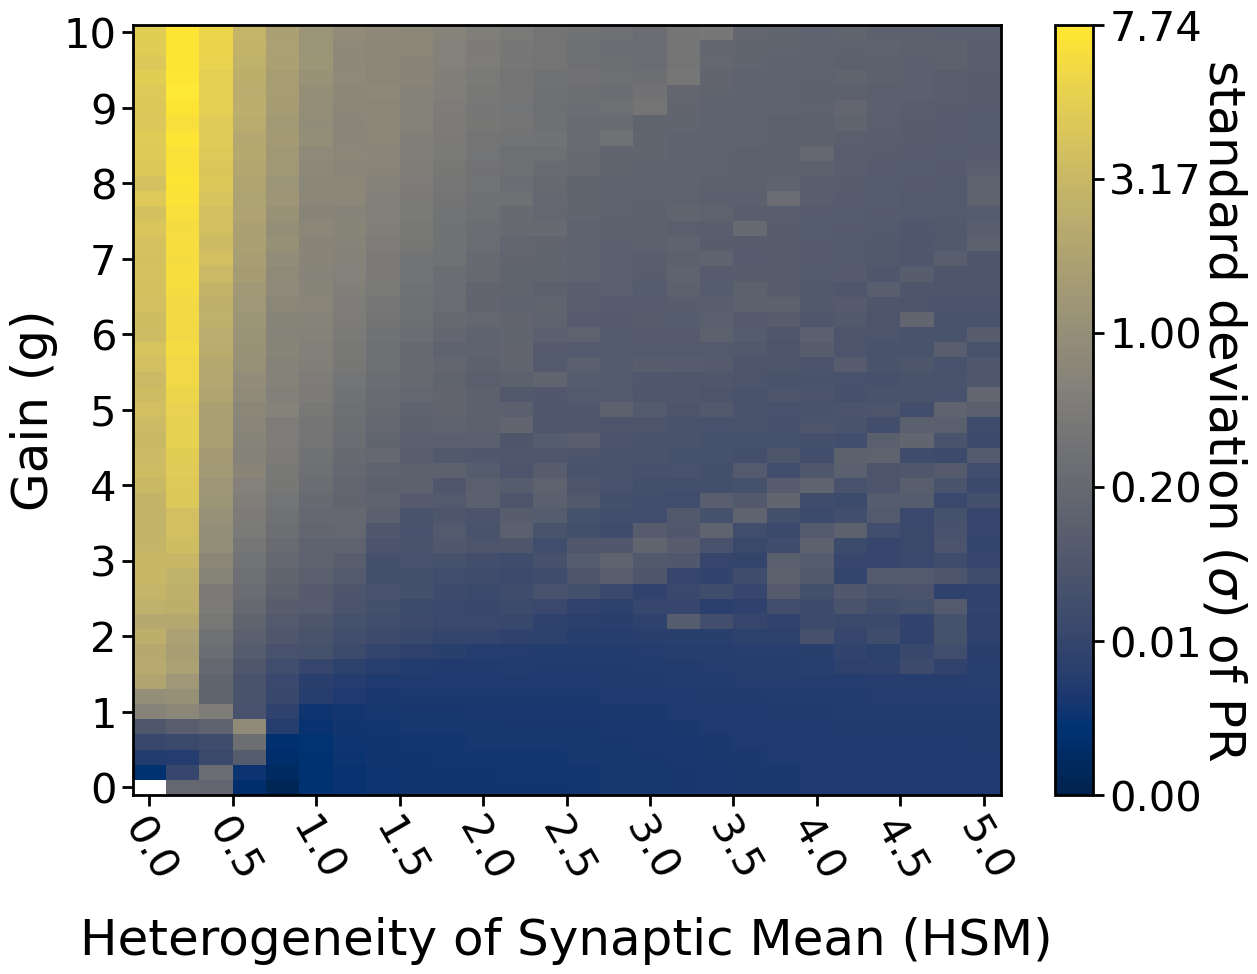

In [9]:
#Std heatmap

plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 36
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

#tick size:
plt.rcParams['xtick.major.size'] = 8    # length of major ticks
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2  # width of major ticks
plt.rcParams['ytick.major.width'] = 2


mask = (HSMs_sorted != 10) 

# Put them into a DataFrame
df = pd.DataFrame({
    'G': Gains_sorted[mask],
    'W': Weights_Seeds_sorted[mask],
    'I': Initialisation_Seeds_sorted[mask],
    'HSM': HSMs_sorted[mask],
    'PR': PRs_sorted[mask]
})



# Average over W and I for each (G, HSM) combination
# (If you want to ignore W and I completely, comment the line below and uncomment the next one)
#df_mean = df.groupby(['G', 'HSM'], as_index=False)['L'].mean()
df_mean = df.groupby(['G', 'W', 'I', 'HSM'], as_index=False)['PR'].mean()
df_std = df_mean.groupby(['G', 'HSM'], as_index=False)['PR'].std()


heatmap_data = df_std.pivot_table(index='G', columns='HSM', values='PR', aggfunc='mean')


# Set the (G=0, HSM=0) cell to NaN → will render as white
if 0 in heatmap_data.index and 0 in heatmap_data.columns:
    heatmap_data.loc[0, 0] = np.nan


# for if you do not want to compare between 1000N and 3000N
GLOBAL_VMIN = df_std['PR'].min()
GLOBAL_VMAX = df_std['PR'].max()

print(GLOBAL_VMAX, GLOBAL_VMIN)

plt.figure(figsize=(14,10))

# Use GLOBAL vmin/vmax instead of data-specific min/max
norm = PowerNorm(
    gamma=0.25,
    vmin=GLOBAL_VMIN,  # Changed
    vmax=GLOBAL_VMAX   # Changed
)

cmap = plt.get_cmap('cividis').copy()
cmap.set_bad(color='white')

mesh = plt.pcolormesh(
    heatmap_data.columns,
    heatmap_data.index,
    heatmap_data.values,
    shading='auto',
    cmap=cmap,
    norm=norm
)

cbar = plt.colorbar(mesh)
cbar.set_label('standard deviation ($\sigma$) of PR', rotation=270, labelpad=20)
cbar.ax.yaxis.set_label_coords(5.0, 0.5)  # Adjust position if needed


cbar.ax.minorticks_off()

n_ticks = 6  
tick_positions = np.linspace(0, 1, n_ticks)

# Use GLOBAL values for tick calculation
data_min = GLOBAL_VMIN  # Changed
data_max = GLOBAL_VMAX  # Changed
gamma = 0.25
tick_values = data_min + (data_max - data_min) * (tick_positions ** (1/gamma))

rounded_labels = [f"{v:.02f}" for v in tick_values]

cbar.set_ticks(tick_values)
cbar.set_ticklabels(rounded_labels)



# plt.pcolormesh(heatmap_data.columns, heatmap_data.index, heatmap_data.values,
#                shading='auto', cmap='inferno')
# plt.colorbar(label='$\sigma$ of PR')
plt.xlabel('Heterogeneity of Synaptic Mean (HSM)', labelpad = 20)
plt.ylabel('Gain (g)')
# plt.title('Uncertainty of PR')
# plt.title('Heatmap of MLEs vs HSMs per Gains')

#for increasing the width of the plot edge line
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

#for increasing the width of the edge line of the colour bar
cbar.outline.set_linewidth(2)

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
filename = f"PR_0.2s_shortened_uncertainty_{timestamp}.png"
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PR map PNGs for Gain and HSM", filename)

#filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PRs map gain 1-3 HSM 0-0.1", filename)


#for increasing the width of the plot edge line
ax = plt.gca()
ax.tick_params(axis='x', rotation=300)
ax.xaxis.set_major_locator(MaxNLocator(nbins=11))
ax.yaxis.set_major_locator(MaxNLocator(nbins=11))

plt.savefig(filepath, dpi=300)

plt.show()

# **Coefficient of Variation (std/mean) Map**

CV range: [0.0000, 0.6282]


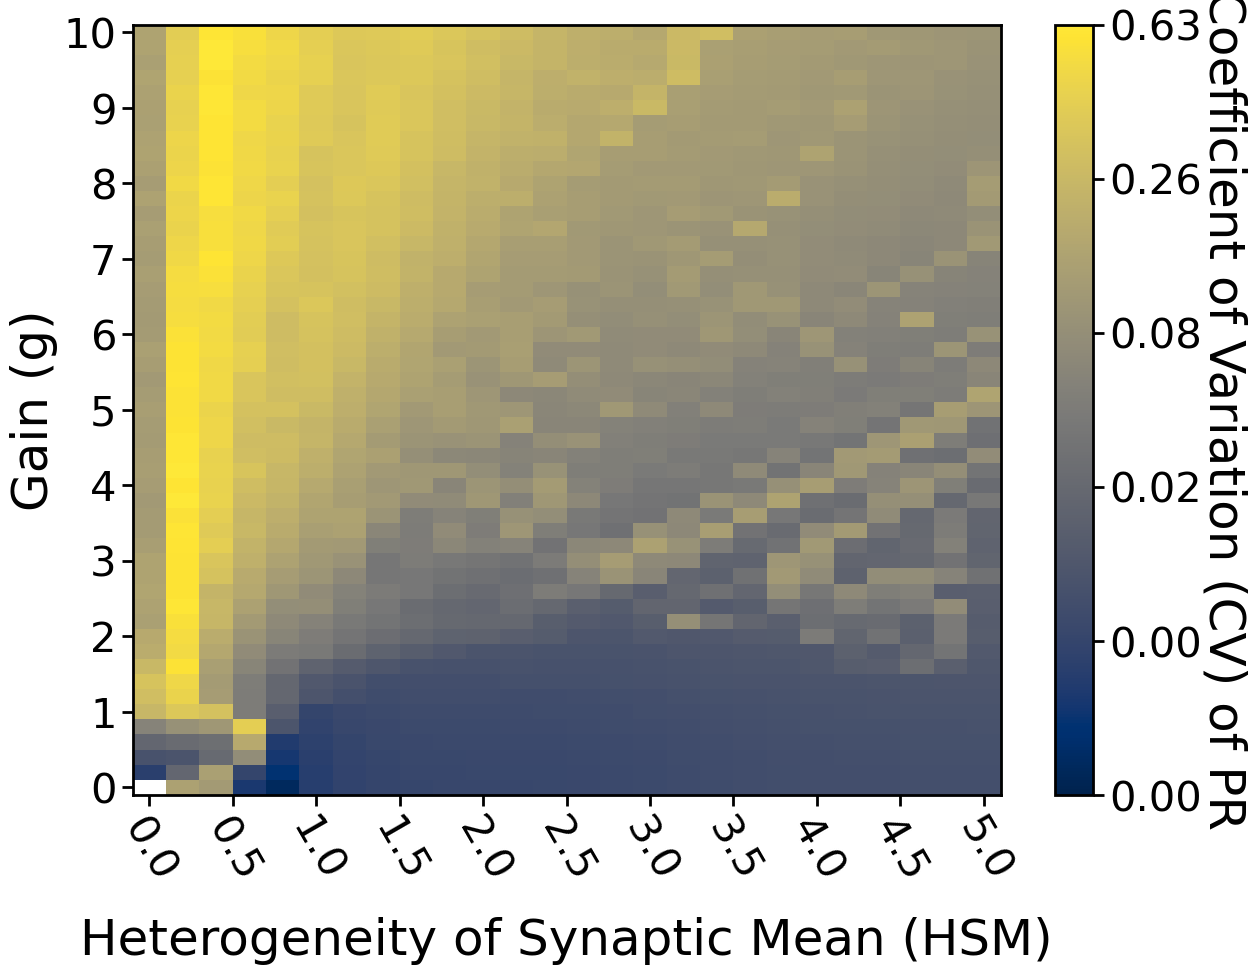

In [12]:
#CV heatmap (coefficient of variation = std / mean)
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 36
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2

mask = (HSMs_sorted != 10)

df = pd.DataFrame({
    'G': Gains_sorted[mask],
    'W': Weights_Seeds_sorted[mask],
    'I': Initialisation_Seeds_sorted[mask],
    'HSM': HSMs_sorted[mask],
    'PR': PRs_sorted[mask]
})

# Average over W and I for each (G, HSM, W, I) combination first
df_mean = df.groupby(['G', 'W', 'I', 'HSM'], as_index=False)['PR'].mean()

# Compute std and mean across W/I seeds for each (G, HSM)
df_std  = df_mean.groupby(['G', 'HSM'], as_index=False)['PR'].std()
df_avg  = df_mean.groupby(['G', 'HSM'], as_index=False)['PR'].mean()

# Merge and compute CV = std / mean
df_cv = df_std.merge(df_avg, on=['G', 'HSM'], suffixes=('_std', '_mean'))
df_cv['CV'] = df_cv['PR_std'] / df_cv['PR_mean'].abs()  # abs() guards against negative means

heatmap_data = df_cv.pivot_table(index='G', columns='HSM', values='CV', aggfunc='mean')

# Set the (G=0, HSM=0) cell to NaN → will render as white
if 0 in heatmap_data.index and 0 in heatmap_data.columns:
    heatmap_data.loc[0, 0] = np.nan

GLOBAL_VMIN = df_cv['CV'].min()
GLOBAL_VMAX = df_cv['CV'].max()
print(f"CV range: [{GLOBAL_VMIN:.4f}, {GLOBAL_VMAX:.4f}]")

plt.figure(figsize=(14, 10))

norm = PowerNorm(
    gamma=0.25,
    vmin=GLOBAL_VMIN,
    vmax=GLOBAL_VMAX
)

cmap = plt.get_cmap('cividis').copy()
cmap.set_bad(color='white')

mesh = plt.pcolormesh(
    heatmap_data.columns,
    heatmap_data.index,
    heatmap_data.values,
    shading='auto',
    cmap=cmap,
    norm=norm
)

cbar = plt.colorbar(mesh)
cbar.set_label('Coefficient of Variation (CV) of PR', rotation=270, labelpad=20)
cbar.ax.yaxis.set_label_coords(5.0, 0.5)
cbar.ax.minorticks_off()

n_ticks = 6
tick_positions = np.linspace(0, 1, n_ticks)
gamma = 0.25
tick_values = GLOBAL_VMIN + (GLOBAL_VMAX - GLOBAL_VMIN) * (tick_positions ** (1 / gamma))
rounded_labels = [f"{v:.2f}" for v in tick_values]
cbar.set_ticks(tick_values)
cbar.set_ticklabels(rounded_labels)

plt.xlabel('Heterogeneity of Synaptic Mean (HSM)', labelpad=20)
plt.ylabel('Gain (g)')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)
cbar.outline.set_linewidth(2)

ax.tick_params(axis='x', rotation=300)
ax.xaxis.set_major_locator(MaxNLocator(nbins=11))
ax.yaxis.set_major_locator(MaxNLocator(nbins=11))

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
filename = f"PR_0.2s_shortened_CV_{timestamp}.png"
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PR map PNGs for Gain and HSM", filename)
plt.savefig(filepath, dpi=300)
plt.show()
